# Classifier Model to Predict Diabetes

Jessica Serrao 


April 12, 2022

#### Load and Prepare Data

In [26]:
#import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [27]:
#import data 
train = pd.read_csv("train_diabetes.csv")
train =train.set_index("Unnamed: 0")
X_train = train.drop('Outcome',axis=1) #feature matrix 
y_train = train['Outcome'] #target vector 
valid = pd.read_csv('val_diabetes.csv')
valid = valid.set_index("Unnamed: 0")
X_valid = valid.drop('Outcome',axis=1)
y_valid = valid['Outcome']

In [28]:
#convert to numpy array to train the model 
X_train = X_train.values
y_train = y_train.values
X_valid = X_valid.values
y_valid = y_valid.values

In [29]:
#reshape the data
X_train = X_train.T
y_train = y_train.reshape(1,X_train.shape[1])

X_valid = X_valid.T
y_valid = y_valid.reshape(1,X_valid.shape[1])
print("Shape of X_train : ", X_train.shape)
print("Shape of y_train : ", y_train.shape)
print("Shape of X_valid : ", X_valid.shape)
print("Shape of y_valid : ", y_valid.shape)

Shape of X_train :  (8, 460)
Shape of y_train :  (1, 460)
Shape of X_valid :  (8, 154)
Shape of y_valid :  (1, 154)


#### Custom Logistic Regression

In [30]:
#create the sigmoid function 
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [31]:
def model(X, Y, learning_rate,lambda_val, epochs):
    
    m = X_train.shape[1] #number of observations 
    n = X_train.shape[0] #number of features 
    
    W = np.zeros((n,1))
    B = 0
    
    cost_list = []
    
    for i in range(epochs):
        
        Z = np.dot(W.T, X) + B
        A = sigmoid(Z) #probabilistic predictions 
        
        #L2 regularization 
        ridge_reg_term = (lambda_val / 2 * m) * np.sum(np.square(W))
        
        # cost function
        cost = -(1/m)*np.sum( Y*np.log(A) + (1-Y)*np.log(1-A)) + ridge_reg_term
        
        # Gradient Descent
        dW = (1/m)*np.dot(A-Y, X.T)
        dB = (1/m)*np.sum(A - Y)
        
        W = W - learning_rate*dW.T
        B = B - learning_rate*dB
        
        # Keeping track of our cost function value
        cost_list.append(cost)
        
        #check if the cost is decreasing and print 10 instances 
        if(i%(epochs/10) == 0):
            print("cost after ", i, "iteration is : ", cost)
        
    return W, B, cost_list

In [32]:
W, B, cost_list = model(X_train, y_train, learning_rate=0.00001,lambda_val=0.3, epochs=500)

cost after  0 iteration is :  0.6931471805599452
cost after  50 iteration is :  0.6582872709403937
cost after  100 iteration is :  0.6536934694442538
cost after  150 iteration is :  0.6505768838804121
cost after  200 iteration is :  0.648122751098139
cost after  250 iteration is :  0.6461769530792298
cost after  300 iteration is :  0.6446707491356702
cost after  350 iteration is :  0.6435477061503628
cost after  400 iteration is :  0.6427567716269472
cost after  450 iteration is :  0.6422522182883408


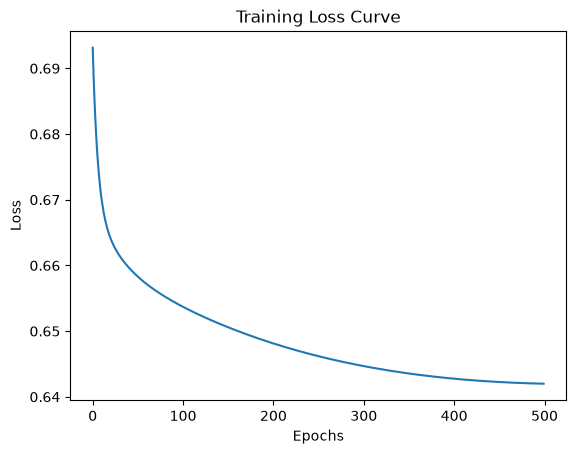

In [33]:
plt.plot(np.arange(len(cost_list)), cost_list)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

Model quickly converges at iteration 500 due to a very tiny learning rate of 0.00001. 

In [ ]:
# Use the W and B created by training on X_train / y_train
validation_probabilities = sigmoid(np.dot(W.T, X_valid) + B)

# Convert probabilities to 0/1 predictions
validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

# Flatten arrays for sklearn metrics
y_valid_flat = y_valid.flatten()
validation_predictions_flat = validation_predictions.flatten()

print(
    "Validation accuracy:",
    round(accuracy_score(y_valid_flat, validation_predictions_flat), 3)
)

print(
    "Validation F1 score:",
    round(f1_score(y_valid_flat, validation_predictions_flat), 3)
)

print("\nValidation confusion matrix:")
print(
    confusion_matrix(
        y_valid_flat,
        validation_predictions_flat
    )
)

Validation accuracy: 0.597
Validation F1 score: 0.162

Validation confusion matrix:
[[86  5]
 [57  6]]


### Experimentation

In [39]:
W, B, cost_list = model(X_train, y_train, learning_rate=0.001,lambda_val=0.4, epochs=500)

cost after  0 iteration is :  0.6931471805599452
cost after  50 iteration is :  1.1181291489869432
cost after  100 iteration is :  2.3566253794954464
cost after  150 iteration is :  1.543364034690181
cost after  200 iteration is :  3.2411359414382015
cost after  250 iteration is :  4.6362381019037775
cost after  300 iteration is :  3.0511129694531274
cost after  350 iteration is :  2.1181807763383884
cost after  400 iteration is :  1.963285711130666
cost after  450 iteration is :  1.8411206785369756


Here in this iteration if we plot the model on the training data using a larger learning rate of 0.001 we can see that the cost function is not decreasing. The choice of a lambda value for regularization of 0.4 was to remain conservative  as 0.4 is a relatively unbiased value, neither high nor low, thus reducing the likelihood of overfitting or underfitting of the data. 

In [40]:
W, B, cost_list = model(X_train, y_train, learning_rate=0.0001,lambda_val=0.4, epochs=500)

cost after  0 iteration is :  0.6931471805599452
cost after  50 iteration is :  0.6457337818025762
cost after  100 iteration is :  0.6560617009059647
cost after  150 iteration is :  0.6698542374241493
cost after  200 iteration is :  0.6819467380194311
cost after  250 iteration is :  0.6916724151443445
cost after  300 iteration is :  0.6993898251828414
cost after  350 iteration is :  0.7055977026357041
cost after  400 iteration is :  0.7107206885804911
cost after  450 iteration is :  0.7150774870704082


Decreasing the value of the learning rate to 0.0001 appears to render some change in the cost function values however the values are still not decreasing and appear divergent in behavior. 

In [41]:
W, B, cost_list = model(X_train, y_train, learning_rate=0.00001,lambda_val=0.5, epochs=500)

cost after  0 iteration is :  0.6931471805599452
cost after  50 iteration is :  0.6588029268566717
cost after  100 iteration is :  0.6546624840830224
cost after  150 iteration is :  0.6520766135113018
cost after  200 iteration is :  0.6502475411888657
cost after  250 iteration is :  0.6490214474440662
cost after  300 iteration is :  0.648319405626941
cost after  350 iteration is :  0.6480713318447808
cost after  400 iteration is :  0.6482124808702636
cost after  450 iteration is :  0.6486846411697881


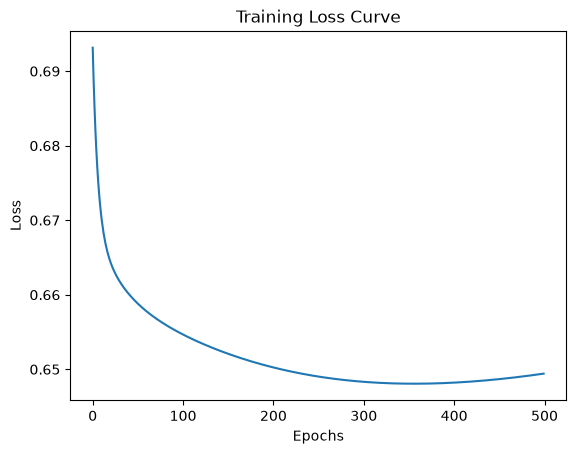

In [43]:
plt.plot(np.arange(len(cost_list)),cost_list)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

In [44]:
W, B, cost_list = model(X_train, y_train, learning_rate=0.00001,lambda_val=0.4, epochs=500)

cost after  0 iteration is :  0.6931471805599452
cost after  50 iteration is :  0.6585450988985327
cost after  100 iteration is :  0.6541779767636381
cost after  150 iteration is :  0.6513267486958569
cost after  200 iteration is :  0.6491851461435024
cost after  250 iteration is :  0.6475992002616481
cost after  300 iteration is :  0.6464950773813056
cost after  350 iteration is :  0.6458095189975719
cost after  400 iteration is :  0.6454846262486054
cost after  450 iteration is :  0.6454684297290644


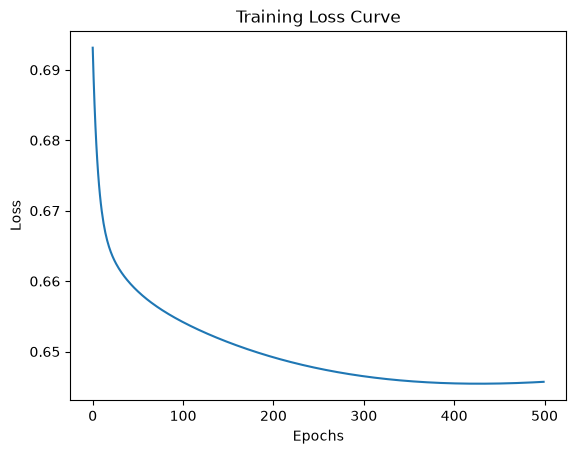

In [45]:
plt.plot(np.arange(len(cost_list)),cost_list)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

Decreasing the value of the learning rate to 0.00001 yields a decreasing loss function. Toggling between a lambda of 0.5 and 0.4 we can see that 0.4 provides better convergence with the 500th iteration of the function because 0.5 appears to indicate a slight increase at the 500th iteration rather than convergence. 

#### Scikit-Learn Logistic Regression

In [46]:
#import packages and wrangle data 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import pandas as pd 
train = pd.read_csv("train_diabetes.csv")
train =train.set_index("Unnamed: 0")
X_train = train.drop('Outcome',axis=1) #feature matrix 
y_train = train['Outcome'] #target vector 
train.shape

(460, 9)

In [47]:
valid = pd.read_csv('val_diabetes.csv')
valid = valid.set_index("Unnamed: 0")
X_valid = valid.drop('Outcome',axis=1)
y_valid = valid['Outcome']
valid.shape

(154, 9)

In [48]:
LOGREG_L2 = {}

In [52]:
#Logistic Regression with L2 Regularization
import pprint
lambdas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for values in lambdas:
    c = 1/values
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='l2', solver='liblinear')
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_valid)
    d = {values: metrics.accuracy_score(y_valid, y_pred)}  
    LOGREG_L2.update(d) 
pprint.pprint(LOGREG_L2)

{0.1: 0.7142857142857143,
 0.2: 0.7337662337662337,
 0.3: 0.7337662337662337,
 0.4: 0.7467532467532467,
 0.5: 0.7532467532467533,
 0.6: 0.7597402597402597,
 0.7: 0.7597402597402597,
 0.8: 0.7597402597402597,
 0.9: 0.7597402597402597}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

In [53]:
LOGREG_L1 = {}

In [54]:
#Logisitic Regression with L1 Regularization
lambdas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for values in lambdas:
    c = 1/values
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='l1', solver='liblinear')
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_valid)
    d = {values: metrics.accuracy_score(y_valid, y_pred)}  
    LOGREG_L1.update(d) 
pprint.pprint(LOGREG_L1)

{0.1: 0.7142857142857143,
 0.2: 0.7142857142857143,
 0.3: 0.7142857142857143,
 0.4: 0.7142857142857143,
 0.5: 0.7142857142857143,
 0.6: 0.7142857142857143,
 0.7: 0.7142857142857143,
 0.8: 0.7207792207792207,
 0.9: 0.7207792207792207}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

In [55]:
LOGREG_EN = {}

In [56]:
lambdas = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for values in lambdas:
    c = 1/values 
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='elasticnet', l1_ratio=0.5,solver='saga')
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_valid)
    d = {values: metrics.accuracy_score(y_valid, y_pred)}  
    LOGREG_EN.update(d) 
pprint.pprint(LOGREG_EN)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

{0.1: 0.6493506493506493,
 0.2: 0.6493506493506493,
 0.3: 0.6493506493506493,
 0.4: 0.6493506493506493,
 0.5: 0.6493506493506493,
 0.6: 0.6493506493506493,
 0.7: 0.6493506493506493,
 0.8: 0.6493506493506493,
 0.9: 0.6493506493506493}


The logistic regression models above were evaluated for various values of lambda ranging from 0.1 to 0.9. The term 'C' given in the sklearn.LogisticRegression function describes the inverse of regularization or $C=\frac{1}{\lambda}$ thus the values from the lambdas list are applied inversely to C. Utilizing LogisiticRegression from the sklearn package, I was able to evaluate the various lambadas across the different regularizations applied to logisitic regression.

In running the elastic net penalty convergence did not occur until 'max_iter' or the number of iterations was set to 10,000 thus for consistency across all models 'max_iter' was designated as 10,000. To determine the best lambda I examined the results for the "inflection point" or the spot at which the 'curvature' of the data changes. The lambda values influences the complexity of the model. A smaller lambda can lead to overfitting while a larger lambda can cause underfitting of the data. For L2 Ridge Regularization of Logistic Regression the best lambda is 0.6. While for L1 Lasso Regularization of Logistic Regression the best lambda is 0.8. With Elastic Net regularization all the output appears to be the same and thus 0.1 is chosen as the best lambda because the data does not appear to have an 'inflection point'. 

Regularization introduces bias into the model and decreases the variance. By modifiying the loss function with a penalty term the estimates of the coefficents shrink. Therefore we expect a higher value of $\lambda$ to cause the coefficents to be pushed towards 0. 

In [57]:
#L2 Regularization
classifier = LogisticRegression(C=1/0.6 , max_iter=10000, penalty='l2', solver='liblinear')
classifier.fit(X_train, y_train)
classifier.coef_ 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


array([[ 0.08399217,  0.0248091 , -0.01408124, -0.00247566, -0.00100755,
         0.05909543,  0.64311073,  0.01695639]])

With the optimal value of lambda of 0.6 for the L2 Regularization of Logistic Regression the coefficients are somewhat close to zero however some values are shown to deviate such as 0.084, 0.059, and 0.64. Four features in this case are shown to deviate by more than 0.02 units from a baseline of 0. Model interpretability with L2 Regularization is more difficult given that all predictors will be included in the final model and their values will be very close to zero but not zero itself. 

In [58]:
#L2 Regularization with high and low lambda
lambda_adj = [5,15,75,150]
for values in lambda_adj:
    print(values)
    c = 1/values 
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='l2', solver='liblinear')
    classifier.fit(X_train, y_train)
    print(classifier.coef_)


5
[[ 9.40685453e-02  1.65839149e-02 -2.41386606e-02 -3.28103179e-03
  -1.69831832e-04  1.73964122e-02  3.43001447e-01  4.03948263e-03]]
15
[[ 9.83463214e-02  1.41088449e-02 -2.85180547e-02 -3.45265411e-03
   1.24878156e-04  4.56455383e-03  1.94159190e-01 -3.99820296e-05]]
75
[[ 0.09430538  0.01282283 -0.03117378 -0.00348089  0.00029365 -0.00238085
   0.05523448 -0.00130375]]
150
[[ 0.08683232  0.01257963 -0.03139578 -0.00346502  0.00030741 -0.00345673
   0.0288529  -0.00055405]]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

As would be expected with an increase in regularization through the increase in the hyperparameter $\lambda$ we see that more of the coefficients with L2 Regularization are shifted towards zero. Since the parameter 'C' in the function reflects the inverse of regularization, as C gets smaller the model coefficients become smaller and the regularization penalty becomes more prominent. With a lambda value of 150, for example, only two features are shown to differ by more than 0.02 units. 

In [59]:
#L1 Regularization
classifier = LogisticRegression(C=1/0.8 , max_iter=10000, penalty='l1', solver='liblinear')
classifier.fit(X_train, y_train)
classifier.coef_ 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


array([[ 0.07887928,  0.02924937, -0.00965878, -0.00190862, -0.00139434,
         0.08240477,  0.70101958,  0.02397199]])

With the optimal lambda of 0.8 from L1 Regularization of Logistic Regression the coefficients are somewhat close to 0 and given that Lasso Regression or L1 Regularization shrinks the less important features to 0 this aligns well. We have five features that differ by more than 0.02 units according to these coefficients.  

In [60]:
#L1 Regularization with high and low lambda
lambda_adj = [5,15,75,150]
for values in lambda_adj:
    print(values)
    c = 1/values 
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='l1', solver='liblinear')
    classifier.fit(X_train, y_train)
    print(classifier.coef_)

5
[[ 0.07564002  0.02317858 -0.01579797 -0.00181433 -0.00067167  0.0485988
   0.07489298  0.01455557]]
15
[[ 0.08309102  0.0127718  -0.03023293 -0.00292996  0.0002429   0.
   0.          0.        ]]
75
[[ 1.88156339e-02  1.10308599e-02 -2.90022834e-02 -1.57441027e-03
   6.65498698e-05  0.00000000e+00  0.00000000e+00  2.03826196e-03]]
150
[[ 0.          0.01017741 -0.02581376  0.          0.          0.
   0.          0.        ]]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

The coefficients for the varying levels of regularization with L1 differ greatly from the coefficients for L2 for the increasing levels of regularization. As is expected with L1 Regularization many of the less important features are given a value of 0. The features for which a 0 was assigned after increasing regularization, were features 6,7 and 8 which correspond to BMI, DiabetesPedigreeFunction and Age. According to this model those features are thus considered less important. With higher levels of regularization such as a lambda value of 150, features 1,4,and 5 were also considered less important and these corresponded to Pregnancies, SkinThickness and Insulin. 

In [61]:
#Elastic Net Regularization
classifier = LogisticRegression(C=0.1 , max_iter=10000, penalty='elasticnet', l1_ratio=0.5,solver='saga')
classifier.fit(X_train, y_train)
classifier.coef_

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


array([[ 0.09133455,  0.01239305, -0.03189498, -0.00336988,  0.00033204,
        -0.00293278,  0.        , -0.00079681]])

With the optimal lambda of 0.1 for elastic net regularization many of the coefficients (4 out of 8) are negative as opposed to only 3 for Lasso and Ridge Regression. Several of the coefficients are close to 0 and one is actually deemed as 0 according to the output. 

In [62]:
#Elastic Net Regularization with high and low lambda
lambda_adj = [5,15,75,150]
for values in lambda_adj:
    print(values)
    c = 1/values 
    classifier = LogisticRegression(C=c , max_iter=10000, penalty='elasticnet',l1_ratio=0.5, solver='saga')
    classifier.fit(X_train, y_train)
    print(classifier.coef_)

5
[[ 0.0953102   0.01253198 -0.03190574 -0.00342673  0.00033652 -0.00323921
   0.00756851 -0.00152385]]
15
[[ 8.74759624e-02  1.22434185e-02 -3.18946199e-02 -3.32112968e-03
   3.25562706e-04 -2.69210981e-03  0.00000000e+00 -9.28219666e-05]]
75


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  w

[[ 0.05545873  0.01168125 -0.03043457 -0.00278593  0.00021023  0.
   0.          0.00038988]]
150
[[ 1.55091879e-02  1.11424701e-02 -2.86116486e-02 -1.47063039e-03
   4.70637948e-05  0.00000000e+00  0.00000000e+00  2.59121520e-03]]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In the elastic net regularization, increasing the hyperparameter for regularization led to feature 6 and 7 being designated as 0. As regularization increased the values for the coefficents became orders of magnitude smaller approaching values of 0. 

#### Final Test Evaluation

In [63]:
import pandas as pd 
test = pd.read_csv('test_diabetes.csv')
test = test.set_index("Unnamed: 0")
X_test = test.drop('Outcome',axis=1)
y_test = test['Outcome']
test.shape

(154, 9)

In [66]:
#L1 Regularization on Test
c = 1/0.8
classifier = LogisticRegression(C=c , max_iter=10000, penalty='l1', solver='liblinear')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test) 
print(f'accuracy score: {metrics.accuracy_score(y_test, y_pred)}')
print(f'f1 score: {metrics.f1_score(y_test,y_pred)}')

accuracy score: 0.8311688311688312
f1 score: 0.6976744186046512


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


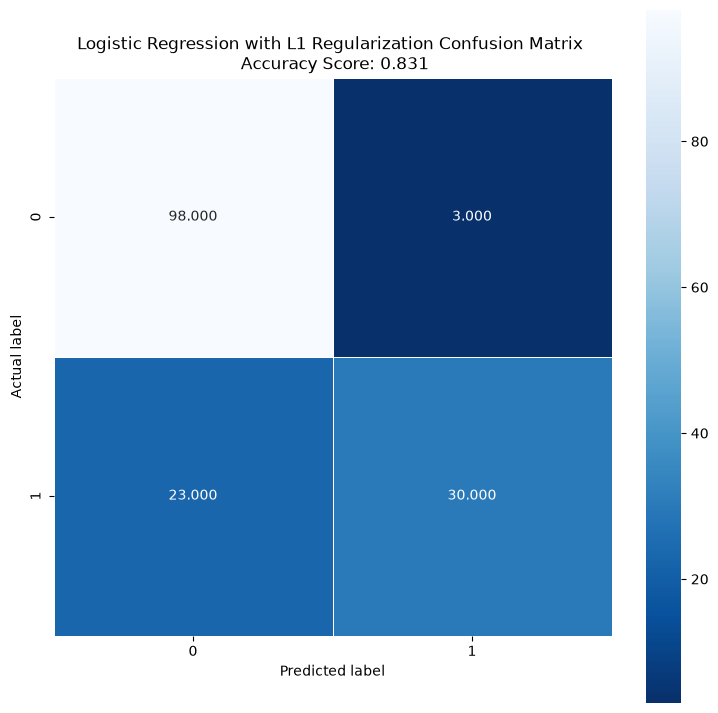

In [69]:
#confusion matrix for L1 Regularization 
import seaborn as sns 
cm = metrics.confusion_matrix(y_test, y_pred)
score = round(metrics.accuracy_score(y_test, y_pred),3)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title("Logistic Regression with L1 Regularization Confusion Matrix \n {}".format(all_sample_title), size = 12);

After comparing regularization approaches using the validation set, the L1-regularized logistic regression model was selected for final evaluation. On the held-out test set, the selected model achieved an accuracy of 83.1% and an F1 score of 0.69. Because the outcome classes were imbalanced, F1 score was used as the primary performance measure because it balances precision and recall. The confusion matrix showed 98 true negatives, 3 false positives, 23 false negatives, and 30 true positives. L1 regularization also improves interpretability by shrinking less informative feature coefficients to zero; however, this model is an educational analysis and should not be used for clinical diagnosis.